/scratch/local/31388220/ipykernel_1146794/3785631108.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis/rdf_plus_msd_stacked_ACS_decompose.png
Saved: /blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis/rdf_plus_msd_stacked_ACS_decompose.pdf


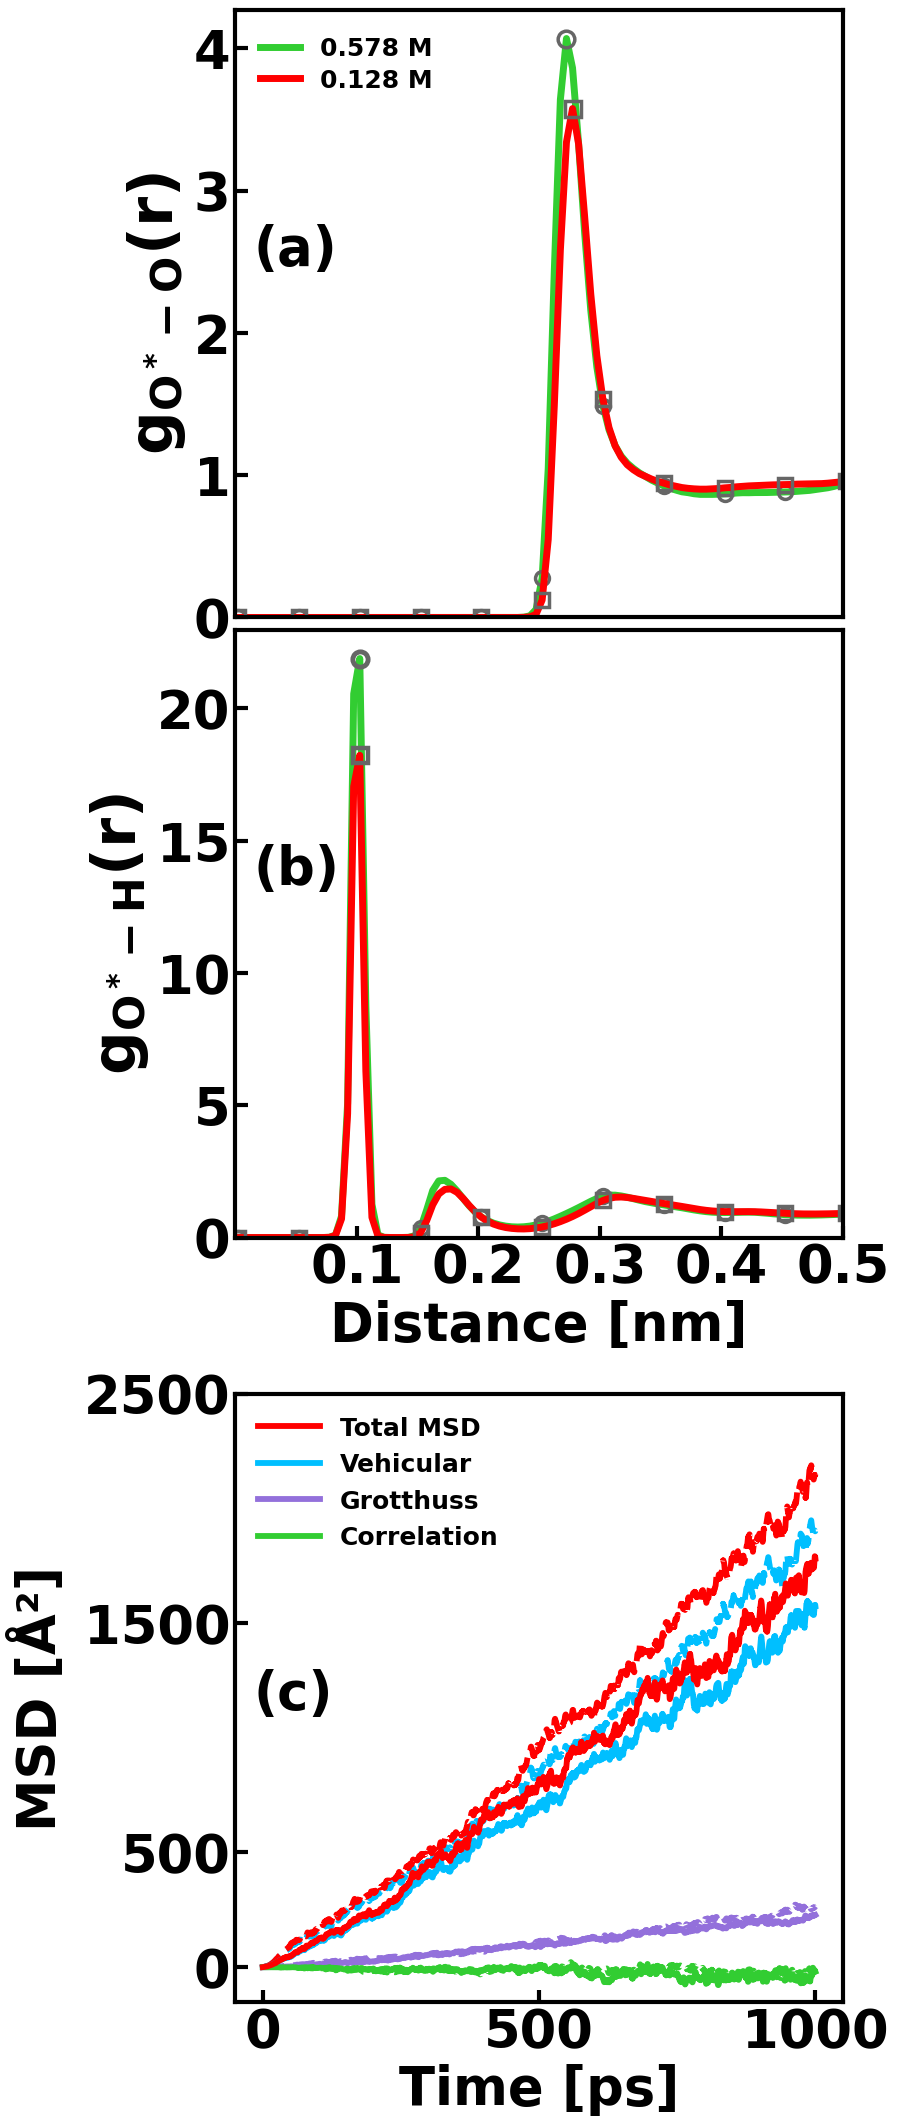

In [25]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# OUTPUT
# =========================================================
OUTDIR = "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis"
OUTNAME = "rdf_plus_msd_stacked_ACS_decompose"

# =========================================================
# RDF INPUTS
# =========================================================
RDF_PANEL1_FILES = {
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/O_O_mean_std_rdf.csv",
}

RDF_PANEL2_FILES = {
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/O_H_mean_std_rdf.csv",
}

RDF_PANELS = [
    dict(tag="(a)", files=RDF_PANEL1_FILES, ylab=r"$\mathbf{g_{O^*-O}(r)}$"),
    dict(tag="(b)", files=RDF_PANEL2_FILES, ylab=r"$\mathbf{g_{O^*-H}(r)}$"),
]

# =========================================================
# MSD INPUTS
# =========================================================
DT_FS = 1.0

MSD_FILES = {
     "A2": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
    "P1": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
}

# =========================================================
# GLOBAL STYLE
# =========================================================
TEXT_SIZE = 38
AX_W = 3.0
TICK_W = 3.0
TICK_LEN = 9

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": TEXT_SIZE,
    "axes.labelsize": TEXT_SIZE,
    "legend.fontsize": 18,   # smaller legend
    "xtick.labelsize": TEXT_SIZE,
    "ytick.labelsize": TEXT_SIZE,
    "axes.linewidth": AX_W,
    "xtick.major.width": TICK_W,
    "ytick.major.width": TICK_W,
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "savefig.dpi": 600,
})

# =========================================================
# RDF STYLE
# =========================================================
RDF_LINEWIDTH = 5
RDF_MS = 10
RDF_MEW = 2.5

RDF_STYLE = {
    "0.578 M": dict(color="limegreen", marker="o"),
    "0.128 M": dict(color="red", marker="s"),
}

MARKER_GREY = "0.4"

RDF_XMAX_NM = 0.5
RDF_YMIN = 0

PEAK_XMIN = 0.10
PEAK_XMAX = 0.35

# smaller legend and safely inside plot
RDF_LEGEND_X = 0.35
RDF_LEGEND_Y = 0.98
RDF_LEGEND_SIZE = 18

# =========================================================
# MSD STYLE
# =========================================================
SMOOTH = 15
LINE_W = 4.2

COL_CONT  = "deepskyblue"
COL_DISC  = "mediumpurple"
COL_CORR  = "limegreen"
COL_TOTAL = "red"

LS_A2 = "--"
LS_P1 = "-"

MSD_XMIN = -50
MSD_XMAX = 1050
MSD_YMIN = -150      # near zero
MSD_YMAX = 2500

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def bold_ticks(ax):
    for t in ax.get_xticklabels():
        t.set_fontweight("bold")
    for t in ax.get_yticklabels():
        t.set_fontweight("bold")

def load_rdf_mean_std(path):
    data = np.genfromtxt(path, delimiter=",", names=True)
    r = np.asarray(data["r_Angstrom"], float)
    g = np.asarray(data["g_mean"], float)
    s = np.asarray(data["g_std"], float)
    return r, g, s

def first_peak(x, y):
    mask = (x >= PEAK_XMIN) & (x <= PEAK_XMAX)
    if not np.any(mask):
        return None
    idx = np.argmax(y[mask])
    i = np.where(mask)[0][idx]
    return x[i], y[i]

def smooth(y, w):
    if w <= 1:
        return y
    return pd.Series(y).rolling(
        window=w,
        center=True,
        min_periods=max(2, w // 3)
    ).mean().to_numpy()

def load_msd_csv(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "time":      df["time"],           # was "timestep"
        "cont_mean": df["cont_sq_mean"],   # was "cont_sq"
        "disc_mean": df["disc_sq_mean"],   # was "disc_sq"
        "corr_mean": df["corr_mean"],      # this one was already correct
        "tot_mean":  df["total_mean"],     # was "true_total_sq"
    })
def plot_rdf_panel(ax, panel, show_legend=False):
    for label, path in panel["files"].items():
        rA, g, s = load_rdf_mean_std(path)
        r = rA / 10.0
        st = RDF_STYLE[label]

        ax.plot(
            r,
            g,
            color=st["color"],
            lw=RDF_LINEWIDTH,
            label=label if show_legend else None
        )

        ax.plot(
            r,
            g,
            linestyle="None",
            marker=st["marker"],
            markevery=10,
            markersize=RDF_MS,
            markerfacecolor="none",
            markeredgecolor=MARKER_GREY,
            markeredgewidth=RDF_MEW
        )

        pk = first_peak(r, g)
        if pk is not None:
            ax.plot(
                pk[0],
                pk[1],
                marker=st["marker"],
                markersize=RDF_MS * 1.2,
                markerfacecolor="none",
                markeredgecolor=MARKER_GREY,
                markeredgewidth=RDF_MEW
            )

    ax.set_xlim(0, RDF_XMAX_NM)
    ax.set_ylim(bottom=RDF_YMIN)

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        width=TICK_W,
        length=TICK_LEN,
        top=False,
        right=False
    )

    # remove zero label on x
    xticks = np.arange(0.1, RDF_XMAX_NM + 0.01, 0.1)
    ax.set_xticks(xticks)

    ax.set_ylabel(panel["ylab"], fontsize=44, fontweight="bold")
    ax.yaxis.label.set_fontweight("bold")
    bold_ticks(ax)

    ax.text(
        0.03,
        0.58,
        panel["tag"],
        transform=ax.transAxes,
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    ax.set_box_aspect(1)

    if show_legend:
        leg = ax.legend(
            frameon=False,
            loc="upper right",
            bbox_to_anchor=(RDF_LEGEND_X, RDF_LEGEND_Y),
            fontsize=RDF_LEGEND_SIZE,
            handlelength=1.6,
            borderaxespad=0.2,
            labelspacing=0.3
        )
        for t in leg.get_texts():
            t.set_fontweight("bold")

def plot_msd_system(ax, df, linestyle):
    x = df["time"].values * DT_FS * 0.001  # fs -> ps

    def draw(mean, color):
        m = smooth(mean, SMOOTH)
        ax.plot(x, m, lw=LINE_W, color=color, linestyle=linestyle)

    draw(df["cont_mean"], COL_CONT)
    draw(df["disc_mean"], COL_DISC)
    draw(df["corr_mean"], COL_CORR)
    draw(df["tot_mean"],  COL_TOTAL)

def plot_msd_panel(ax):
    data = {k: load_msd_csv(v) for k, v in MSD_FILES.items()}

    # 0.128 M -> A2 -> dashed
    plot_msd_system(ax, data["A2"], LS_A2)

    # 0.578 M -> P1 -> solid
    plot_msd_system(ax, data["P1"], LS_P1)

    ax.set_xlim(MSD_XMIN, MSD_XMAX)
    ax.set_ylim(MSD_YMIN, MSD_YMAX)

    ax.set_xticks([0, 500, 1000])
    ax.set_yticks([0, 500, 1500, 2500])
    ax.minorticks_off()

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        width=TICK_W,
        length=TICK_LEN,
        top=False,
        right=False
    )

    ax.set_xlabel("Time [ps]", fontweight="bold")
    ax.set_ylabel("MSD [Å²]", fontweight="bold", labelpad=12)

    bold_ticks(ax)

    ax.text(
        0.03,
        0.48,
        "(c)",
        transform=ax.transAxes,
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    msd_legend_handles = [
    plt.Line2D([0], [0], color=COL_TOTAL, lw=LINE_W, linestyle="-",  label="Total MSD"),
    plt.Line2D([0], [0], color=COL_CONT,  lw=LINE_W, linestyle="-",  label="Vehicular"),
    plt.Line2D([0], [0], color=COL_DISC,  lw=LINE_W, linestyle="-",  label="Grotthuss"),
    plt.Line2D([0], [0], color=COL_CORR,  lw=LINE_W, linestyle="-",  label="Correlation"),
]

    leg = ax.legend(
    handles=msd_legend_handles,
    loc="upper left",
    frameon=False,
    fontsize=18,
    handlelength=2.5
)

    for t in leg.get_texts():
        t.set_fontweight("bold")
    for t in leg.get_texts():
        t.set_fontweight("bold")

    ax.set_box_aspect(1)

# =========================================================
# MAIN
# =========================================================
def main():
    os.makedirs(OUTDIR, exist_ok=True)

    import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 24))

gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[1, 1, 1],
    hspace=0.02   # small spacing between first two plots
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

axes = [ax1, ax2, ax3]

# add extra space ONLY before MSD panel
ax3.set_position([
    ax3.get_position().x0,
    ax3.get_position().y0 - 0.06,
    ax3.get_position().width,
    ax3.get_position().height
])

    # RDF panel 1
plot_rdf_panel(axes[0], RDF_PANELS[0], show_legend=True)

     # remove x-axis from first plot
axes[0].tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    # RDF panel 2
plot_rdf_panel(axes[1], RDF_PANELS[1], show_legend=False)
axes[1].set_xlabel("Distance [nm]", fontweight="bold")

    # MSD panel
plot_msd_panel(axes[2])

fig.tight_layout()

png = os.path.join(OUTDIR, OUTNAME + ".png")
pdf = os.path.join(OUTDIR, OUTNAME + ".pdf")

fig.savefig(png, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")

print("Saved:", png)
print("Saved:", pdf)

if __name__ == "__main__":
    main()

Saved: /blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis/rdf_plus_msd_stacked_ACS_decompose.png
Saved: /blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis/rdf_plus_msd_stacked_ACS_decompose.pdf


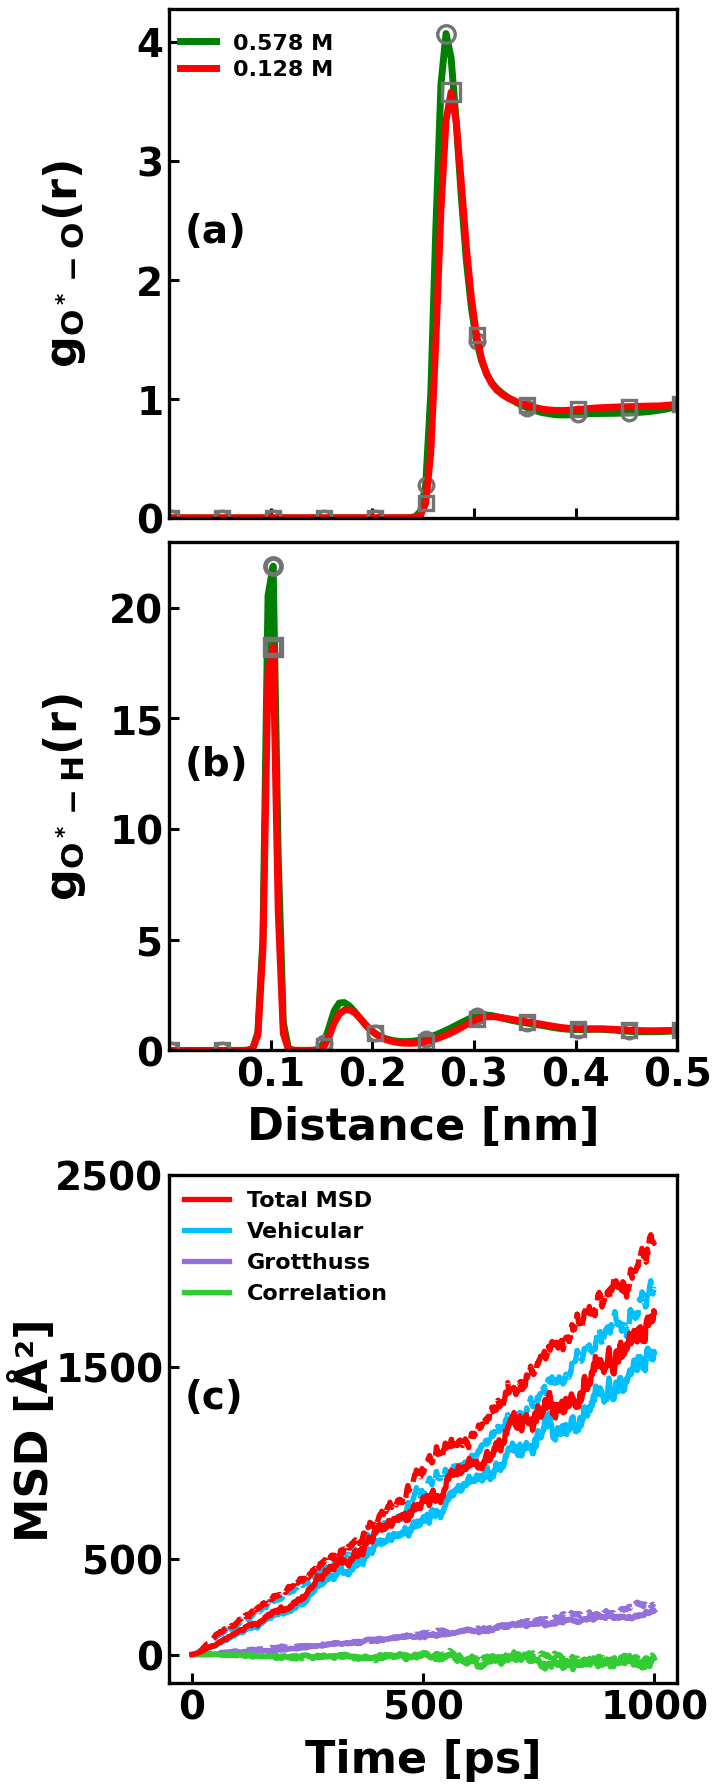

In [12]:
#!/usr/bin/env python3
"""
RDF + MSD stacked plot, restyled to match the compact ACS look:
- bold global font weight, editable vector text (pdf/ps fonttype 42)
- ticks in, only on left/bottom axes
- consistent y-label offset across all three stacked panels
- square (box_aspect) panels
- hand-drawn "pencil" sketch style on RDF markers
- shared format_axes() / make_ticklabels_bold() helpers

Panels:
  (a) RDF O*-O
  (b) RDF O*-H
  (c) MSD decomposition (vehicular / Grotthuss / correlation / total)
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# OUTPUT
# =========================================================
OUTDIR = "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/Analysis"
OUTNAME = "rdf_plus_msd_stacked_ACS_decompose"

# =========================================================
# RDF INPUTS
# =========================================================
RDF_PANEL1_FILES = {
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/O_O_mean_std_rdf.csv",
}
RDF_PANEL2_FILES = {
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/O_H_mean_std_rdf.csv",
}
RDF_PANELS = [
    dict(tag="(a)", files=RDF_PANEL1_FILES, ylab=r"$g_{O^*-O}(r)$"),
    dict(tag="(b)", files=RDF_PANEL2_FILES, ylab=r"$g_{O^*-H}(r)$"),
]

# =========================================================
# MSD INPUTS
# =========================================================
DT_FS = 1.0
MSD_FILES = {
    "A2": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
    "P1": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
}

# =========================================================
# AXIS SETTINGS (RDF)
# =========================================================
RDF_XMAX_NM = 0.5
RDF_YMIN = 0.0
PEAK_XMIN = 0.10
PEAK_XMAX = 0.35
MARK_EVERY = 10

# =========================================================
# FONT / ACS-LIKE GLOBAL STYLE
# =========================================================
FONT_FAMILY = "DejaVu Sans"
TEXT_SIZE = 28
LABEL_SIZE = 32
LEGEND_SIZE = 16
PANEL_TAG_SIZE = 28
AX_W = 2.4
TICK_W = 2.2
TICK_LEN = 7

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": TEXT_SIZE,
    "font.weight": "bold",
    "axes.labelsize": LABEL_SIZE,
    "axes.labelweight": "bold",
    "axes.linewidth": AX_W,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TEXT_SIZE,
    "ytick.labelsize": TEXT_SIZE,
    "xtick.major.width": TICK_W,
    "ytick.major.width": TICK_W,
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.6,
    "ytick.minor.width": 1.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})
mpl.rcParams.update({
    "mathtext.fontset": "custom",
    "mathtext.rm": "DejaVu Sans",
    "mathtext.it": "DejaVu Sans:italic",
    "mathtext.bf": "DejaVu Sans:bold",
})
mpl.rcParams["mathtext.default"] = "regular"

# =========================================================
# RDF STYLE
# =========================================================
RDF_LINEWIDTH = 5
RDF_MS = 10.5
RDF_MEW = 2.4
MARKER_GREY = "0.45"
RDF_STYLE = {
    "0.578 M": dict(color="green", marker="o"),
    "0.128 M": dict(color="red", marker="s"),
}
RDF_LEGEND_LOC = "upper right"
RDF_LEGEND_BBOX = (0.35, 0.98)

# "pencil" / sketch style for markers (hand-drawn ACS look)
SKETCH_SCALE = 0.8
SKETCH_LENGTH = 60.0
SKETCH_RANDOMNESS = 2.0

# =========================================================
# MSD STYLE
# =========================================================
SMOOTH = 15
LINE_W = 3.8
COL_CONT = "deepskyblue"
COL_DISC = "mediumpurple"
COL_CORR = "limegreen"
COL_TOTAL = "red"
LS_A2 = "--"
LS_P1 = "-"
MSD_XMIN = -50
MSD_XMAX = 1050
MSD_YMIN = -150
MSD_YMAX = 2500

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def make_ticklabels_bold(ax):
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)


def load_rdf_mean_std(path):
    data = np.genfromtxt(path, delimiter=",", names=True)
    r = np.asarray(data["r_Angstrom"], float)
    g = np.asarray(data["g_mean"], float)
    s = np.asarray(data["g_std"], float)
    return r, g, s


def first_peak(x, y):
    mask = (x >= PEAK_XMIN) & (x <= PEAK_XMAX)
    if not np.any(mask):
        return None
    idx = np.argmax(y[mask])
    i = np.where(mask)[0][idx]
    return x[i], y[i]


def smooth(y, w):
    if w <= 1:
        return y
    return pd.Series(y).rolling(
        window=w, center=True, min_periods=max(2, w // 3)
    ).mean().to_numpy()


def load_msd_csv(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "time":      df["time"],
        "cont_mean": df["cont_sq_mean"],
        "disc_mean": df["disc_sq_mean"],
        "corr_mean": df["corr_mean"],
        "tot_mean":  df["total_mean"],
    })


def format_axes(ax, show_xticklabels=True):
    """Shared ACS-style axis formatting: ticks in, only left/bottom,
    square panel, bold tick labels."""
    ax.tick_params(
        axis="both", which="major",
        direction="in", width=TICK_W, length=TICK_LEN,
        top=False, right=False, pad=4,
    )
    ax.tick_params(labelbottom=show_xticklabels, labelleft=True)
    ax.set_box_aspect(1)
    make_ticklabels_bold(ax)


def plot_rdf_panel(ax, panel, show_legend=False, show_xticklabels=True):
    for label, path in panel["files"].items():
        rA, g, s = load_rdf_mean_std(path)
        r = rA / 10.0
        st = RDF_STYLE[label]

        ax.plot(
            r, g,
            color=st["color"], lw=RDF_LINEWIDTH,
            label=label if show_legend else None,
        )

        marker_artist, = ax.plot(
            r, g,
            linestyle="None", marker=st["marker"],
            markevery=MARK_EVERY, markersize=RDF_MS,
            markerfacecolor="none", markeredgecolor=MARKER_GREY,
            markeredgewidth=RDF_MEW,
        )
        marker_artist.set_sketch_params(
            scale=SKETCH_SCALE, length=SKETCH_LENGTH,
            randomness=SKETCH_RANDOMNESS,
        )

        pk = first_peak(r, g)
        if pk is not None:
            peak_artist, = ax.plot(
                pk[0], pk[1],
                marker=st["marker"], markersize=RDF_MS * 1.2,
                markerfacecolor="none", markeredgecolor=MARKER_GREY,
                markeredgewidth=RDF_MEW, linestyle="None", zorder=10,
            )
            peak_artist.set_sketch_params(
                scale=SKETCH_SCALE, length=SKETCH_LENGTH,
                randomness=SKETCH_RANDOMNESS,
            )

    ax.set_xlim(0, RDF_XMAX_NM)
    ax.set_ylim(bottom=RDF_YMIN)

    xticks = np.arange(0.1, RDF_XMAX_NM + 0.01, 0.1)
    ax.set_xticks(xticks)

    ax.set_ylabel(panel["ylab"], fontweight="bold")
    ax.yaxis.set_label_coords(-0.16, 0.5)

    ax.text(
        0.03, 0.60, panel["tag"],
        transform=ax.transAxes,
        fontsize=PANEL_TAG_SIZE, fontweight="bold",
        ha="left", va="top",
    )

    format_axes(ax, show_xticklabels=show_xticklabels)

    if show_legend:
        leg = ax.legend(
            frameon=False, loc=RDF_LEGEND_LOC,
            bbox_to_anchor=RDF_LEGEND_BBOX,
            handlelength=1.6, borderaxespad=0.2, labelspacing=0.3,
        )
        for t in leg.get_texts():
            t.set_fontweight("bold")
            t.set_fontfamily(FONT_FAMILY)


def plot_msd_system(ax, df, linestyle):
    x = df["time"].values * DT_FS * 0.001  # fs -> ps

    def draw(mean, color):
        m = smooth(mean, SMOOTH)
        ax.plot(x, m, lw=LINE_W, color=color, linestyle=linestyle)

    draw(df["cont_mean"], COL_CONT)
    draw(df["disc_mean"], COL_DISC)
    draw(df["corr_mean"], COL_CORR)
    draw(df["tot_mean"],  COL_TOTAL)


def plot_msd_panel(ax):
    data = {k: load_msd_csv(v) for k, v in MSD_FILES.items()}

    plot_msd_system(ax, data["A2"], LS_A2)   # 0.128 M -> dashed
    plot_msd_system(ax, data["P1"], LS_P1)   # 0.578 M -> solid

    ax.set_xlim(MSD_XMIN, MSD_XMAX)
    ax.set_ylim(MSD_YMIN, MSD_YMAX)
    ax.set_xticks([0, 500, 1000])
    ax.set_yticks([0, 500, 1500, 2500])
    ax.minorticks_off()

    ax.set_xlabel("Time [ps]", fontweight="bold", labelpad=8)
    ax.set_ylabel("MSD [Å²]", fontweight="bold")
    ax.yaxis.set_label_coords(-0.22, 0.5)

    ax.text(
        0.03, 0.60, "(c)",
        transform=ax.transAxes,
        fontsize=PANEL_TAG_SIZE, fontweight="bold",
        ha="left", va="top",
    )

    format_axes(ax, show_xticklabels=True)

    msd_legend_handles = [
        plt.Line2D([0], [0], color=COL_TOTAL, lw=LINE_W, linestyle="-", label="Total MSD"),
        plt.Line2D([0], [0], color=COL_CONT,  lw=LINE_W, linestyle="-", label="Vehicular"),
        plt.Line2D([0], [0], color=COL_DISC,  lw=LINE_W, linestyle="-", label="Grotthuss"),
        plt.Line2D([0], [0], color=COL_CORR,  lw=LINE_W, linestyle="-", label="Correlation"),
    ]
    leg = ax.legend(
        handles=msd_legend_handles,
        loc="upper left", frameon=False,
        fontsize=LEGEND_SIZE, handlelength=2.0, borderaxespad=0.3,
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
        t.set_fontfamily(FONT_FAMILY)


# =========================================================
# MAIN
# =========================================================
def main():
    os.makedirs(OUTDIR, exist_ok=True)

    fig = plt.figure(figsize=(7, 18))
    gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 0.15, 1], hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[3])   # gs[2] is left empty as a spacer row

    plot_rdf_panel(ax1, RDF_PANELS[0], show_legend=True, show_xticklabels=False)
    plot_rdf_panel(ax2, RDF_PANELS[1], show_legend=False, show_xticklabels=True)
    ax2.set_xlabel("Distance [nm]", fontweight="bold", labelpad=8)

    plot_msd_panel(ax3)

    fig.subplots_adjust(left=0.20, right=0.95, bottom=0.05, top=0.98, hspace=0.06)

    png = os.path.join(OUTDIR, OUTNAME + ".png")
    pdf = os.path.join(OUTDIR, OUTNAME + ".pdf")
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)


if __name__ == "__main__":
    main()